Faber-Jackson Relation plot

In [8]:
import numpy as np
import matplotlib.pyplot as plt

Firstly, we define the different columns from the data file. We are given the Mass and velocity dispersion. Mass and luminosity are proportional so for the plot we have to log the Mass to depict a representation of Absolute Magnitude. 

In [9]:
skiprow, catid, type, sigma_re, mstar = np.loadtxt('cleaned_data.txt', unpack=True) # Data saved as array in text file
yvalues = np.log10(sigma_re)
xvalues = -2.5 * np.log10(mstar) + 5 * np.log10(70) + 25 # Convert star mass to absolute magnitude. star mass is proportional to luminosity, and absolute magnitude is proportional to luminosity. The constant term is the distance modulus for 70 Mpc.

Now we add a linear fit.

In [10]:
M = xvalues
sigma = yvalues

a,b= np.polyfit(M, sigma, 1) # Fit a linear regression to the data
xcoords = np.linspace(np.min(M), np.max(M), 100) # Create an array of x values for the linear regression line
ycoords = a * xcoords + b # Calculate the y values of the linear regression line

Now we have to plot our data in a graph.

Separate by type.

In [11]:
E = type == 0.0
E_S0 = type == 0.5
S0 = type == 1.0
S0_late = type == 1.5

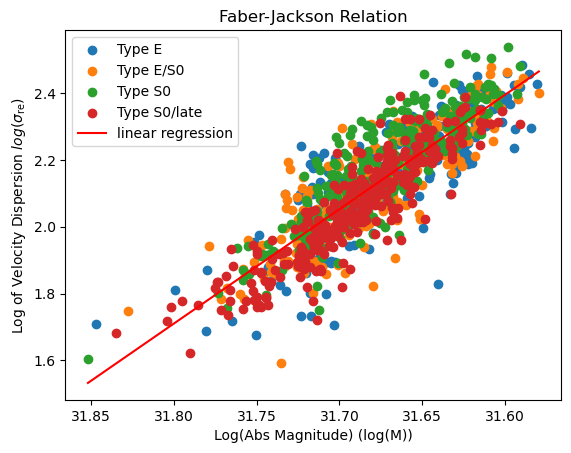

In [12]:
# plt.scatter(xvalues, yvalues, color="black", label="data points") #show data points as black dots

# rewrite for different types

plt.scatter(xvalues[E], yvalues[E], label="Type E")
plt.scatter(xvalues[E_S0], yvalues[E_S0], label="Type E/S0")
plt.scatter(xvalues[S0], yvalues[S0], label="Type S0")
plt.scatter(xvalues[S0_late], yvalues[S0_late], label="Type S0/late")
plt.plot(xcoords, ycoords, color="red", label="linear regression") #show linear regression as red line


plt.gca().invert_xaxis() #invert x axis to match the convention of absolute magnitude (brighter objects have lower magnitudes)

plt.legend(loc="best")
plt.title("Faber-Jackson Relation")
plt.xlabel("Log(Abs Magnitude) (log(M))")
plt.ylabel("Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$")
plt.show()

In [13]:
from scipy.optimize import curve_fit

def relation(Mag, k, b):
    return k * Mag + b

params, covariance = curve_fit(relation, M, sigma)

k = params[0] 

fit = relation(M,k,b)

SS_res = np.sum((sigma - fit)**2)
SS_tot = np.sum((sigma - np.mean(sigma))**2)

R2 = 1- SS_res/SS_tot

corr_coef = np.sqrt(R2)

print("k =", k)
print("R^2 =", R2)
print("r=", corr_coef)
print("SS_res=", SS_res)
print("SS_tot=", SS_tot)


k = -3.421215884011373
R^2 = 0.7391125485804946
r= 0.859716551300773
SS_res= 8.079464477335062
SS_tot= 30.969157134136488


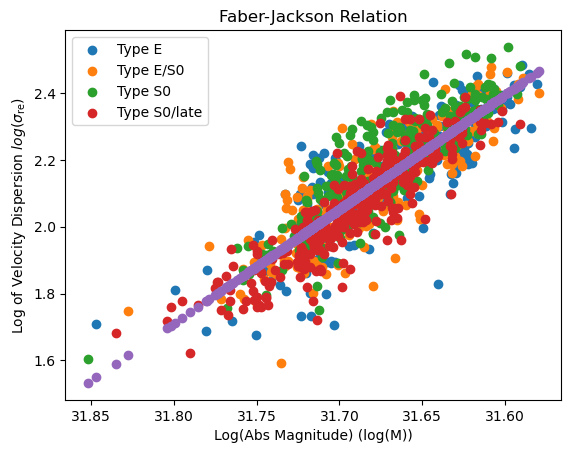

In [14]:
plt.scatter(xvalues[E], yvalues[E], label="Type E")
plt.scatter(xvalues[E_S0], yvalues[E_S0], label="Type E/S0")
plt.scatter(xvalues[S0], yvalues[S0], label="Type S0")
plt.scatter(xvalues[S0_late], yvalues[S0_late], label="Type S0/late")


plt.gca().invert_xaxis() #invert x axis to match the convention of absolute magnitude (brighter objects have lower magnitudes)

plt.legend(loc="best")
plt.title("Faber-Jackson Relation")
plt.xlabel("Log(Abs Magnitude) (log(M))")
plt.ylabel("Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$")
plt.scatter(M, fit)
plt.show()


Text(0, 0.5, '$\\Delta$ Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$')

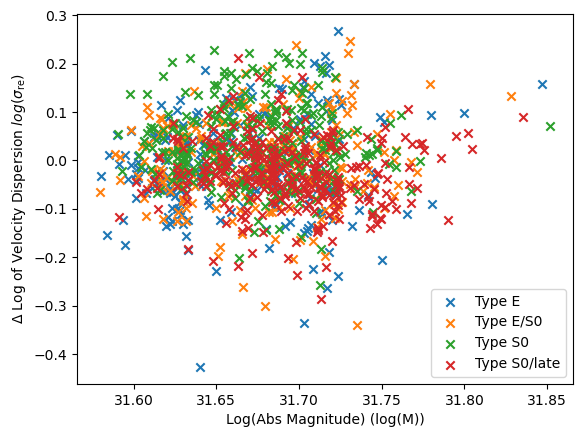

In [30]:
# finding the residuals at each point -> I think we can put this under the curve to show how each point varies

res = sigma - fit

plt.scatter(M[E], res[E], label="Type E", marker = 'x')
plt.scatter(M[E_S0], res[E_S0], label="Type E/S0", marker = 'x')
plt.scatter(M[S0], res[S0], label="Type S0", marker = 'x')
plt.scatter(M[S0_late], res[S0_late], label="Type S0/late", marker = 'x')
plt.legend()


plt.xlabel("Log(Abs Magnitude) (log(M))")
plt.ylabel("$\\Delta$ Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$")

In [35]:
skiprow, catid, type, sigma_re, mstar = np.loadtxt('cleaned_data_mr.txt', unpack=True)

len(type)
len(mstar)

1051

In [36]:
print(np.unique(type))
print(len(sigma_re))
print(len(type))
print(len(mstar))

[0.  0.5 1.  1.5]
1051
1051
1051


In [2]:
import pandas as pd

In [5]:
VM = pd.read_csv('samiDR3VisualMorphology.csv')
VM.head()

,Unnamed: 0,catid,type
0,0,6821,3.0
1,1,6837,3.0
2,2,7139,1.0
3,3,7206,2.0
4,4,7289,0.5


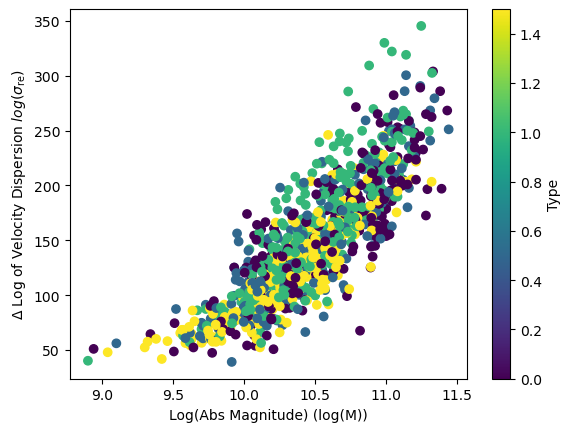

In [37]:
### This one is like the normal one -> think I might take the best bits of both and make it into a good one
## also there is an error coloumn in Stela kinematics SIGMA_RE_ERR -> might want to use?
plt.scatter(
    mstar,
    sigma_re,
    c=type
)

plt.xlabel("Log(Abs Magnitude) (log(M))")
plt.ylabel("$\\Delta$ Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$")
cbar = plt.colorbar()
cbar.set_label('Type')

[-9.   0.   0.5  1.   1.5  2.   2.5  3.   5. ]
2158
2158
2158


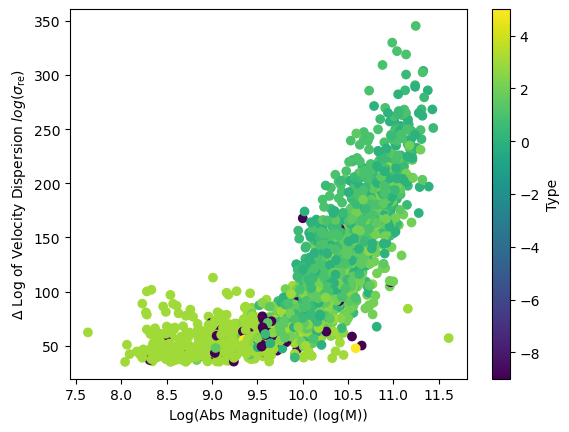

In [38]:
skiprow, catid, type, sigma_re, mstar = np.loadtxt('cleaned_data_all.txt', unpack=True)

print(np.unique(type))
print(len(sigma_re))
print(len(type))
print(len(mstar))
plt.scatter(
    mstar,
    sigma_re,
    c=type
)

plt.xlabel("Log(Abs Magnitude) (log(M))")
plt.ylabel("$\\Delta$ Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$")
cbar = plt.colorbar()
cbar.set_label('Type')

In [ ]:
# this could be a residuals 

Text(0, 0.5, '$\\Delta$ Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$')

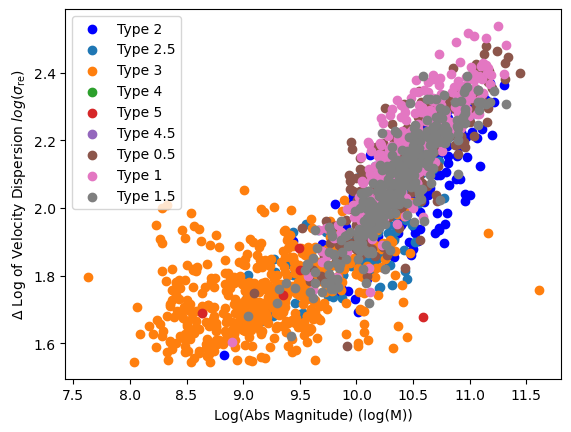

In [29]:
# I think maybe we could add a plot for other galaxies to show it doesnt fit the same pattern


logsigma = np.log10(sigma_re)

#types = np.array[np.unique(type)]


plt.scatter(mstar[type == 2], logsigma[type == 2], label="Type 2", color = 'blue')
plt.scatter(mstar[type == 2.5], logsigma[type == 2.5], label="Type 2.5")
plt.scatter(mstar[type == 3], logsigma[type == 3], label="Type 3")
plt.scatter(mstar[type == 4], logsigma[type == 4], label="Type 4")
plt.scatter(mstar[type == 5], logsigma[type == 5], label="Type 5")
plt.scatter(mstar[type == 4.5], logsigma[type == 4.5], label="Type 4.5")
plt.scatter(mstar[type == 0.5], logsigma[type == 0.5], label="Type 0.5")
plt.scatter(mstar[type == 1], logsigma[type == 1], label="Type 1")
plt.scatter(mstar[type == 1.5], logsigma[type == 1.5], label="Type 1.5")


plt.legend()
plt.xlabel("Log(Abs Magnitude) (log(M))")
plt.ylabel("$\\Delta$ Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$")

Before, we had a look at the proportional relations between Mass (mstar) and Luminosity. To see if our plot actually fits the proportional relation of 4v we can add the specific conversion of Mass to Luminosity.

The dataset also provides m_r which represents the absolute magnitude of a galaxy in the rest-frame r-band, derived from spectral energy distribution (SED) fits, according to SAMI-documentation. That means that we can simply use x=m_r for our plot.

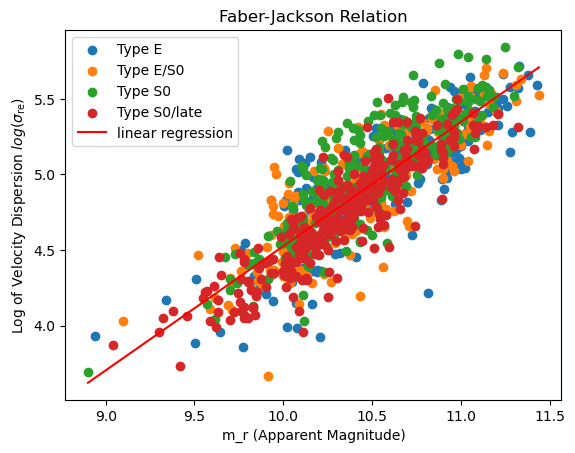

In [12]:
skiprow, catid, type, sigma_re, m_r = np.loadtxt('cleaned_data_mr.txt', unpack=True) # Data saved as array in text file
yvalues = np.log(sigma_re)

xvalues = m_r
sigma = yvalues

a,b= np.polyfit(xvalues, sigma, 1) # Fit a linear regression to the data
xcoords = np.linspace(np.min(xvalues), np.max(xvalues), 100) # Create an array of x values for the linear regression line
ycoords = a * xcoords + b # Calculate the y values of the linear regression line

#Again we seperate by type

E = type == 0.0
E_S0 = type == 0.5
S0 = type == 1.0
S0_late = type == 1.5

#And plot our data points and linear regression line

plt.scatter(xvalues[E], yvalues[E], label="Type E")
plt.scatter(xvalues[E_S0], yvalues[E_S0], label="Type E/S0")
plt.scatter(xvalues[S0], yvalues[S0], label="Type S0")
plt.scatter(xvalues[S0_late], yvalues[S0_late], label="Type S0/late")
plt.plot(xcoords, ycoords, color="red", label="linear regression") #show linear regression as red line


#plt.gca().invert_xaxis() inversion of x axis not necessary anymore

plt.legend(loc="best")
plt.title("Faber-Jackson Relation")
plt.xlabel("m_r (Apparent Magnitude)")
plt.ylabel("Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$")
plt.show()


Once again, we can check this plot's accuracy/probability with the residuals etc.

In [13]:
from scipy.optimize import curve_fit

def relation(m_r, c, b):
    return c * m_r + b

params, covariance = curve_fit(relation, m_r, sigma)

c = params[0] 
b = params[1]

fit = relation(m_r,c,b)

SS_res = np.sum((sigma - fit)**2)
SS_tot = np.sum((sigma - np.mean(sigma))**2)

R2 = 1- SS_res/SS_tot

corr_coef = np.sqrt(R2)

print("c =", c)
print("b =", b)
print("R^2 =", R2)
print("r=", corr_coef)
print("SS_res=", SS_res)
print("SS_tot=", SS_tot)

c = 0.8217171745952245
b = -3.6922121484242867
R^2 = 0.7385467136051117
r= 0.8593874060079725
SS_res= 42.92940489847301
SS_tot= 164.19531569258686
